# 인공지능(CNN) - 위클리 챌린지

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

## Phase 1

- Tabular 데이터셋 Titianic 사용
    1. (공통) 데이터셋 생성
    2. (전처리) 학습, 검증, 테스트 데이터셋 분할하기
    3. (전통 머신러닝) KNN 알고리즘으로 학습 및 예측하기
    4. (전통 머신러닝) Perceptron, SVM, Random Forest, Native Bayes로 학습하기

- 결과 정리
    - Validation과 Test 성능을 함께 평가하는 체계적인 비교 구조 구현
    - 5개 모델 비교
        |Model|Validation Accuracy|Test Accuracy|
        |-|-|-|
        |SVM|0.8015|0.8435|
        |Naive Bayes|0.7634|0.8015|
        |KNN|0.7519|0.7977|
        |Random Forest|0.7786|0.7939|
        |Perceptron|0.6260|0.6756|
        - (결론) Test 기준, SVM이 가장 좋은 성능 제공

In [ ]:
# 1. 데이터셋 생성 - 수집
import kagglehub

# Download latest version
path = kagglehub.dataset_download("euclidsoft/titianic")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titianic' dataset.
Path to dataset files: /kaggle/input/titianic


In [ ]:
# 1.1. 데이터셋 생성 - 호출
import os

excel_path = os.path.join(path, "titanic.xls")
df = pd.read_excel(excel_path)
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.34,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.55,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.55,C22 C26,S,NaN,135.00,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.45,NaN,C,NaN,328.00,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.45,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.22,NaN,C,NaN,304.00,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.22,NaN,C,NaN,NaN,NaN


In [40]:
# 1.2. 데이터셋 X, y 분리하기 (테스트할 인과관계 분리하기)
X = df.drop('survived', axis=1)
y = df['survived']

In [55]:
# 2. (데이터 전처리) 학습, 검증, 테스트 데이터셋 분할하기
    # 분할 기법: 직접 분할, 랜덤 분할

# 2.1. 직접 분할 기법
# (X) Train Data
TRAIN_RATIO = 0.6
X_train_size = int(TRAIN_RATIO * len(X))
X_train_data = df[:X_train_size]

# (X) Validation Data
VALIDATION_RATIO = 0.2
X_validation_size = int(VALIDATION_RATIO * len(X))
X_validation_data = df[X_train_size:X_train_size + X_validation_size]

# (X) Test Data
X_test_data = df[X_train_size + X_validation_size:]

print("X 학습 데이터셋 크기: ", len(X_train_data))
print("X 검증 데이터셋 크기: ", len(X_validation_data))
print("X 테스트 데이터셋 크기: ", len(X_test_data))


# (y) Train Data
TRAIN_RATIO = 0.6
y_train_size = int(TRAIN_RATIO * len(y))
y_train_data = df[:y_train_size]

# (y) Validation Data
VALIDATION_RATIO = 0.2
y_validation_size = int(VALIDATION_RATIO * len(y))
y_validation_data = df[y_train_size:y_train_size + y_validation_size]

# (y) Test Data
y_test_data = df[y_train_size + y_validation_size:]

print("y 학습 데이터셋 크기: ", len(y_train_data))
print("y 검증 데이터셋 크기: ", len(y_validation_data))
print("y 테스트 데이터셋 크기: ", len(y_test_data))

X 학습 데이터셋 크기:  785
X 검증 데이터셋 크기:  261
X 테스트 데이터셋 크기:  263
y 학습 데이터셋 크기:  785
y 검증 데이터셋 크기:  261
y 테스트 데이터셋 크기:  263


In [68]:
# 2.2. 랜덤 분할 기법
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
X_train_data, X_temp_data, y_train_data, y_temp_data = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_validation_data, X_test_data, y_validation_data, y_test_data = train_test_split(
    X_temp_data, y_temp_data, test_size=0.5, stratify=y_temp_data, random_state=42
)

print("X 학습 데이터셋 크기: ", len(X_train_data))
print("X 검증 데이터셋 크기: ", len(X_validation_data))
print("X 테스트 데이터셋 크기: ", len(X_test_data))

print("학습 데이터셋 크기: ", len(y_train_data))
print("검증 데이터셋 크기: ", len(y_validation_data))
print("테스트 데이터셋 크기: ", len(y_test_data))

print(X_train_data.columns.tolist())

X 학습 데이터셋 크기:  785
X 검증 데이터셋 크기:  262
X 테스트 데이터셋 크기:  262
학습 데이터셋 크기:  785
검증 데이터셋 크기:  262
테스트 데이터셋 크기:  262
['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']


In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. 사용할 컬럼 정의
numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked']

# 2. 전처리 파이프라인 구성
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [74]:
# 3. (전통 머신러닝) KNN 알고리즘으로 학습 및 예측하기
from sklearn.preprocessing import StandardScaler

# 3.1. 데이터 정규화 (거리 기반 알고리즘이라 스케일 조정이 중요)
X_train_scaled = preprocessor.fit_transform(X_train_data)
X_val_scaled = preprocessor.transform(X_validation_data)
X_test_scaled = preprocessor.transform(X_test_data)

y_train = y_train_data.values
y_val = y_validation_data.values
y_test = y_test_data.values

# 3.2. PyTorch Tensor로 변환 (불필요, Tensor 변환은 딥러닝에 필요)

In [73]:
from sklearn.neighbors import KNeighborsClassifier
# 3.3. K-NN 모델 생성 (K=5 설정)
k = 5
knn_model = KNeighborsClassifier(n_neighbors=k)

# 3.4. 모델 학습
knn_model.fit(X_train_scaled, y_train_data.values.ravel())

KNeighborsClassifier()

In [71]:
# 3.5. 모델 평가
val_accuracy = knn_model.score(X_val_scaled, y_validation_data.values.ravel())
test_accuracy = knn_model.score(X_test_scaled, y_test_data.values.ravel())

print(f"Validation 데이터 정확도: {val_accuracy:.4f}")
print(f"Test 데이터 정확도: {test_accuracy:.4f}")

# 3.6. 샘플 데이터 예측 (첫 번째 테스트 샘플 예측)
sample_idx = 1
sample = X_test_scaled[sample_idx].reshape(1, -1)  # 입력 데이터 형태 맞추기
prediction = knn_model.predict(sample)

print(f"실제값: {y_test_data.iloc[sample_idx]}, 예측값: {prediction[0]}")

Validation 데이터 정확도: 0.5992
Test 데이터 정확도: 0.5267
실제값: 1, 예측값: 0


In [16]:
# 4. (전통 머신러닝) Perceptron, SVM, Random Forest, Naive Bayes로 학습하기
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# 4.1. 모델 정의
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Perceptron': Perceptron(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

results = []

for name, model in models.items():
    
    # y를 1차원 numpy array로 변환 (안전하게 처리)
    y_train_1d = np.asarray(y_train).ravel()
    y_val_1d   = np.asarray(y_val).ravel()
    y_test_1d  = np.asarray(y_test).ravel()
    
    # 모델 학습
    model.fit(X_train_scaled, y_train_1d)
    
    # Validation 성능
    val_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val_1d, val_pred)
    
    # Test 성능
    test_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test_1d, test_pred)
    
    results.append({
        'Model': name,
        'Validation Accuracy': round(val_acc, 4),
        'Test Accuracy': round(test_acc, 4)
    })
    
    print(f"{name:15} | Validation: {val_acc:.4f} | Test: {test_acc:.4f}")

# 결과 테이블 출력
results_df = pd.DataFrame(results)
print("\n=== 모델 성능 비교 (Validation 기준 정렬) ===")
print(results_df.sort_values('Test Accuracy', ascending=False).to_string(index=False))

KNN             | Validation: 0.7519 | Test: 0.7977
Perceptron      | Validation: 0.6260 | Test: 0.6756
SVM             | Validation: 0.8015 | Test: 0.8435
Random Forest   | Validation: 0.7786 | Test: 0.7939
Naive Bayes     | Validation: 0.7634 | Test: 0.8015

=== 모델 성능 비교 (Validation 기준 정렬) ===
        Model  Validation Accuracy  Test Accuracy
          SVM               0.8015         0.8435
  Naive Bayes               0.7634         0.8015
          KNN               0.7519         0.7977
Random Forest               0.7786         0.7939
   Perceptron               0.6260         0.6756


## Phase 2

- CNN
    1. (공통) 데이터셋 생성
    2. (전처리) 증강(Data Augmentation) 기법 적용 및 비교하기
    3. (딥러닝) 활성화 함수 출력 및 시각화
    4. (딥러닝) MLP 모델 설계 및 분류 수행하기
    5. (딥러닝) CNN 모델 구성 및 이미지 분류

- 증강
    - 교재는 PIL 사용하고 있으나, AI 기반 사용 시 torchvision 사용 (원인 추적 시작)
        - 강사님은 어떤 이유로 교재에서 PIL 선택했는지? 근본 선택
        - 왜 다른 것을 사용하고 있는지? 실무에서는 PIL을 사용할 경우 오래 걸리기 때문 (시급성 고려)
    - 증강 방법의 변화 과정
        1. (근본성 ⭐️⭐️⭐️, 편의성 ⭐️) Base on PIL, Numpy
        2. (근본성 ⭐️⭐️, 편의성 ⭐️⭐️) `torchvision.transforms` ✅
        3. (근본성 ⭐️, 편의성 ⭐️⭐️⭐️) Albumentations
    - (소결) 시급성 고려하여 torchvision.transforms로 구현 우선
        - (Reimplementation) 추후, PIL로 재구현
            - **Low-level Reimplementation 시 지향해야 할 방향성**
                - 이해를 목적으로 할 것 (성능 최적화가 목적이 아님)
                - 한 번에 모두 바꾸지 말고, 점진적으로 바꾸기
                - "이 부분이 왜 이렇게 설계되었는가?" 계속 질문하기
                - 고수준 API가 숨기고 있는 복잡성 직접 경험하기
                - 추후 다시 고수준 API로 돌아왔을 때, 그 가치를 제대로 느끼기

- 활성화 함수
    - 해당 과정을 통해 MLP, CNN을 구현할 때 어떤 활성화 함수를 사용할지 판단하는 데 도움
    - Sigmoid가 근본이고, 나머지는 대부분 기존 활성화 함수가 갖는 문제점을 개선한 형태임
        - $ \sigma(x) = \frac{1}{1 + e^{-x}} $
    - (배경) 실제 생물학적 뉴런의 동작 방식
        - 뉴런은 다른 뉴런으로부터 전기 신호를 받음
        - 입력 신호의 총합이 "일정 수준 이상"이 되면, 전기 신호를 발화
        - 이 발화가 완전한 0 또는 1이 아니라, 입력 강도에 따라 **점진적 발화 확률이 증가**함
        - (소결) 실제 뉴런은 입력의 강도에 따라 반응하는 확률적, 연속적인 특성을 가짐
    - (한계) 초기 인공 뉴런 모델의 경우 계단 함수(Step Function)을 사용
        - 해당 함수는 x=0에서 불연속
        - 생물 뉴런의 연속적인 특성을 제대로 반영하지 못함
        - (소결) Backpropagation(역전파) 알고리즘 사용 불가 (점진적 가중치 수정 불가)
    - (해결) Sigmoid 함수의 등장
        - 역전파의 연쇄 법칙(체인 룰)을 반영하기 위해 미분 가능한 활성화 함수 필요
        - Sigmoid는 해당 문제를 해결하면서, 0 또는 1로만 출력 가능해 생물학적 유사성도 가짐

    - (기타) 깊이 다룰만한 주제
        - 비선형(Non-linearity)가 왜 필요한가?
        - Vanishing Gradient 문제의 메커니즘
        - Dying ReLU 문제(왜 한 번 죽은 뉴런은 회복이 안 되는가)
        - GELU의 설계 철학: 왜 단순한 ReLU가 아니라 확률적 특성을 섞었는가?
        - 활성화 함수와 Optimizer의 상호작용: Adam + ReLU 조합이 왜 잘 맞는가?
        - 현대 모델에서 활성화 함수 선택의 기준: ResNet vs Transformer vs MLP-Mixer 등의 차이


- 결과 정리
    - MLP 모델
        - 증강을 사용하지 않았을 때
            ```bash
                Epoch [1/5]
                Train Loss: 0.5151 | Train Acc: 81.47%
                Test  Loss: 0.4091  | Test  Acc: 85.19%
                --------------------------------------------------
                Epoch [2/5]
                Train Loss: 0.3670 | Train Acc: 86.61%
                Test  Loss: 0.3845  | Test  Acc: 86.01%
                --------------------------------------------------
                Epoch [3/5]
                Train Loss: 0.3299 | Train Acc: 87.87%
                Test  Loss: 0.3496  | Test  Acc: 87.32%
                --------------------------------------------------
                Epoch [4/5]
                Train Loss: 0.3055 | Train Acc: 88.70%
                Test  Loss: 0.3434  | Test  Acc: 87.34%
                --------------------------------------------------
                Epoch [5/5]
                Train Loss: 0.2860 | Train Acc: 89.24%
                Test  Loss: 0.3406  | Test  Acc: 88.02%
                --------------------------------------------------
            ```
        - 증강을 사용했을 때
            ```bash
                Epoch [1/5]
                Train Loss: 0.7970 | Train Acc: 69.79%
                Test  Loss: 0.5974  | Test  Acc: 77.80%
                --------------------------------------------------
                Epoch [2/5]
                Train Loss: 0.6106 | Train Acc: 77.07%
                Test  Loss: 0.5290  | Test  Acc: 79.64%
                --------------------------------------------------
                Epoch [3/5]
                Train Loss: 0.5563 | Train Acc: 79.20%
                Test  Loss: 0.5225  | Test  Acc: 80.21%
                --------------------------------------------------
                Epoch [4/5]
                Train Loss: 0.5295 | Train Acc: 80.05%
                Test  Loss: 0.4772  | Test  Acc: 82.50%
                --------------------------------------------------
                Epoch [5/5]
                Train Loss: 0.5077 | Train Acc: 81.04%
                Test  Loss: 0.4457  | Test  Acc: 83.27%
                --------------------------------------------------
            ```
    - CNN 모델
        - 증강을 사용하지 않았을 때
            ```bash
            Epoch [1/5]
            Train Loss: 0.4925 | Train Acc: 82.30%
            Test  Loss: 0.3314  | Test  Acc: 87.97%
            --------------------------------------------------
            Epoch [2/5]
            Train Loss: 0.3447 | Train Acc: 87.76%
            Test  Loss: 0.2700  | Test  Acc: 90.35%
            --------------------------------------------------
            Epoch [3/5]
            Train Loss: 0.3038 | Train Acc: 89.13%
            Test  Loss: 0.2594  | Test  Acc: 90.37%
            --------------------------------------------------
            Epoch [4/5]
            Train Loss: 0.2740 | Train Acc: 90.02%
            Test  Loss: 0.2792  | Test  Acc: 89.66%
            --------------------------------------------------
            Epoch [5/5]
            Train Loss: 0.2534 | Train Acc: 90.89%
            Test  Loss: 0.2474  | Test  Acc: 90.81%
            --------------------------------------------------
            ```
        - 증강을 사용했을 때
            ```bash
            Epoch [1/5]
            Train Loss: 0.7779 | Train Acc: 71.22%
            Test  Loss: 0.5047  | Test  Acc: 80.76%
            --------------------------------------------------
            Epoch [2/5]
            Train Loss: 0.5950 | Train Acc: 77.77%
            Test  Loss: 0.4057  | Test  Acc: 84.20%
            --------------------------------------------------
            Epoch [3/5]
            Train Loss: 0.5393 | Train Acc: 80.21%
            Test  Loss: 0.3775  | Test  Acc: 86.17%
            --------------------------------------------------
            Epoch [4/5]
            Train Loss: 0.5019 | Train Acc: 81.64%
            Test  Loss: 0.3393  | Test  Acc: 87.25%
            --------------------------------------------------
            Epoch [5/5]
            Train Loss: 0.4785 | Train Acc: 82.50%
            Test  Loss: 0.3552  | Test  Acc: 86.56%
            --------------------------------------------------
            ```

In [6]:
# 1. (공통) 데이터셋 생성 - 수집(로드) 및 기본 전처리
from torchvision import datasets, transforms

# 데이터 변환 정의
transform = transforms.Compose([
    transforms.ToTensor(), # 이미지를 Tensor로 변환 (값 범위: 0 ~ 1)
])

# Fashion-MNIST 데이터셋 로드
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

class_names = train_dataset.classes
print(f"Train data count: {len(train_dataset)}")
print(f"Test data count: {len(test_dataset)}")
print(f"Class List: {class_names}")

# DataLoader 생성
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.43MB/s]

Train data count: 60000
Test data count: 10000
Class List: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [7]:
# 2. (데이터 전처리) 증강(Data Augmentation)기법 적용 (4, 5번에서 증강 vs 미증강 성능 비교)

# 학습 데이터에 적용할 증강 기법
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),           # 좌우 반전
    transforms.RandomRotation(degrees=10),            # ±10도 회전
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # 약간의 이동
    transforms.ToTensor(),
])

# 학습 데이터에 증강 적용
train_aug_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=False,
    transform=augment_transform
)

# 증강이 적용된 DataLoader
train_aug_loader = DataLoader(
    train_aug_dataset,
    batch_size=batch_size,
    shuffle=True
)

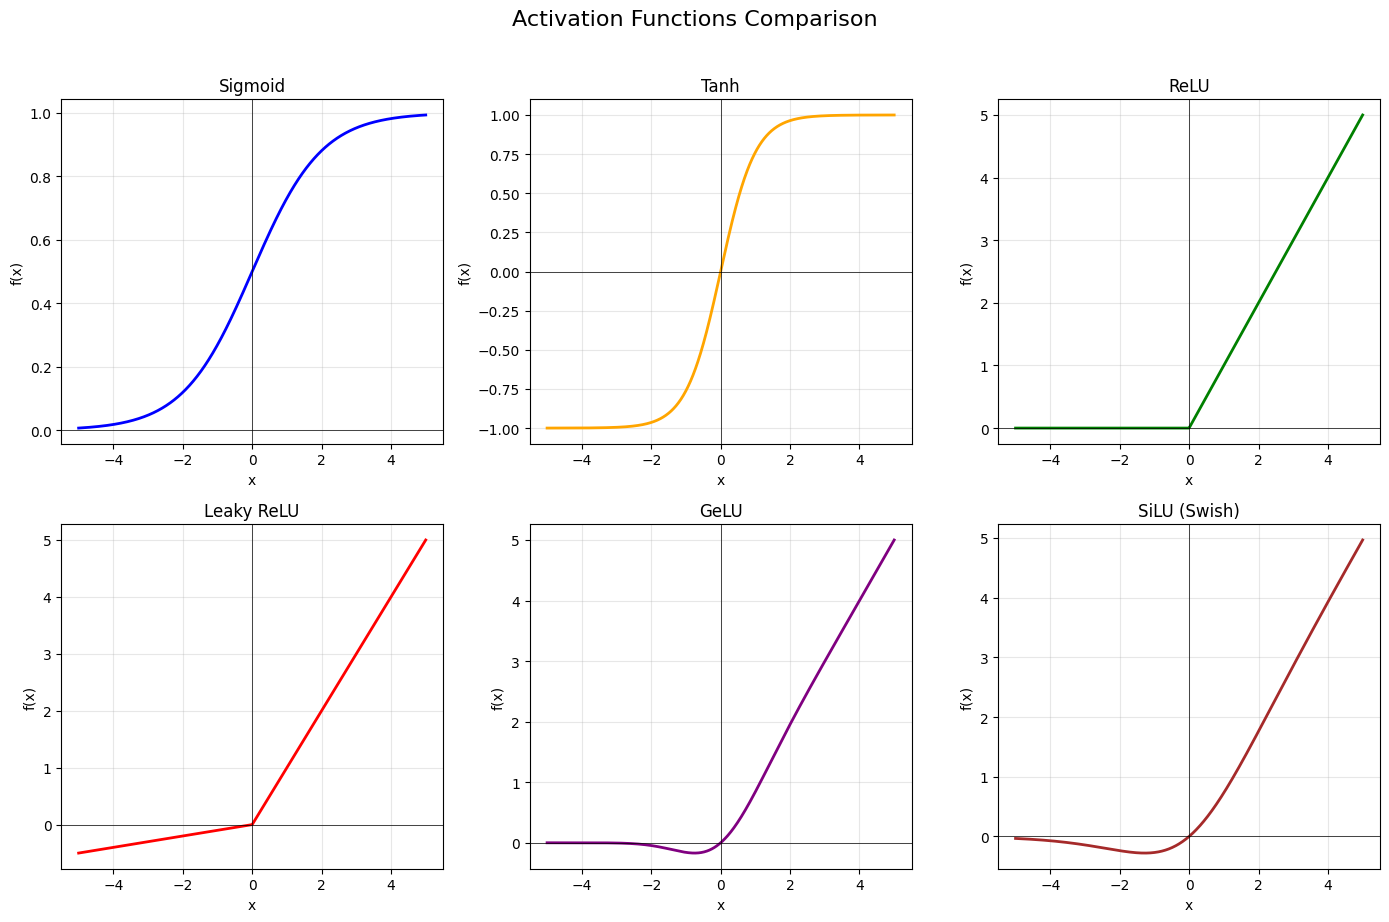

In [8]:
# 3. 활성화 함수 출력 및 시각화
import torch.nn.functional as F

# x 값 범위 설정 (-5 ~ +5)
x = torch.linspace(-5, 5, 1000)

# 주요 활성화 함수 계산
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
relu = F.relu(x)
leaky_relu = F.leaky_relu(x, negative_slope=0.1)
gelu = F.gelu(x)
silu = F.silu(x) # Swish와 동일

# 시각화
plt.figure(figsize=(14, 9))

functions = [
    (sigmoid, 'Sigmoid', 'blue'), # 함수, 타이틀 이름, 색상 순
    (tanh, 'Tanh', 'orange'), 
    (relu, 'ReLU', 'green'), 
    (leaky_relu, 'Leaky ReLU', 'red'), 
    (gelu, 'GeLU', 'purple'), 
    (silu, 'SiLU (Swish)', 'brown'), 
]

for i, (func, title_name, color) in enumerate(functions, 1):
    plt.subplot(2, 3, i)
    plt.plot(x.numpy(), func.numpy(), color=color, linewidth=2)
    plt.title(title_name)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True, alpha=0.3)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)

plt.suptitle("Activation Functions Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# 4. MLP 모델 설계 및 분류 수행하기

# MLP 모델 설계 - 정의
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10):
        super(MLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
        # 활성화 함수는 forward에서 직접 사용 (ReLU)
        
    def forward(self, x):
        # 입력 shape: [batch_size, 1, 28, 28] → [batch_size, 784]
        x = x.view(x.size(0), -1)  
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)           # 마지막 층은 softmax 전에 logit 출력
        
        return x
    
# MLP 모델 설계 - 모델, 손실함수, 옵티마이저 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# MLP 모델 설계 - 학습 함수 구현
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 통계
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# MLP 모델 설계 - 평가 함수 구현
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# MLP 모델로 분류 실행
num_epochs = 5

for epoch in range(num_epochs):
    # train_loss, train_acc = train(model, train_loader, criterion, optimizer, device) # 증강 없이 학습
    train_loss, train_acc = train(model, train_aug_loader, criterion, optimizer, device) # 증강 적용해서 학습
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test  Loss: {test_loss:.4f}  | Test  Acc: {test_acc:.2f}%")
    print("-" * 50)

Epoch [1/5]
  Train Loss: 0.8080 | Train Acc: 69.13%
  Test  Loss: 0.5790  | Test  Acc: 78.53%
--------------------------------------------------
Epoch [2/5]
  Train Loss: 0.6130 | Train Acc: 76.80%
  Test  Loss: 0.5341  | Test  Acc: 80.67%
--------------------------------------------------
Epoch [3/5]
  Train Loss: 0.5606 | Train Acc: 78.74%
  Test  Loss: 0.4908  | Test  Acc: 81.49%
--------------------------------------------------
Epoch [4/5]
  Train Loss: 0.5297 | Train Acc: 79.90%
  Test  Loss: 0.4986  | Test  Acc: 81.38%
--------------------------------------------------
Epoch [5/5]
  Train Loss: 0.5105 | Train Acc: 80.82%
  Test  Loss: 0.4770  | Test  Acc: 82.18%
--------------------------------------------------


In [11]:
# 5. CNN 모델 구성 및 이미지 분류

# CNN 모델 설계 - 정의
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # 첫 번째 컨볼루션 블록
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 두 번째 컨볼루션 블록
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Fully Connected Layer
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # 입력: [batch_size, 1, 28, 28]
        
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # [B, 32, 14, 14]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # [B, 64, 7, 7]
        
        x = x.view(x.size(0), -1)                        # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x
    
# CNN 모델 설계 - 모델, 손실함수, 옵티마이저 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# CNN 모델 설계 - 학습 함수 구현(MLP와 동일하여 생략)
# CNN 모델 설계 - 평가 함수 구현(MLP와 동일하여 생략)

# CNN 모델로 분류 실행
num_epochs = 5

for epoch in range(num_epochs):
    # train_loss, train_acc = train(model, train_loader, criterion, optimizer, device) # 증강 없이 학습
    train_loss, train_acc = train(model, train_aug_loader, criterion, optimizer, device) # 증강 적용해서 학습
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test  Loss: {test_loss:.4f}  | Test  Acc: {test_acc:.2f}%")
    print("-" * 50)

Epoch [1/5]
  Train Loss: 0.7779 | Train Acc: 71.22%
  Test  Loss: 0.5047  | Test  Acc: 80.76%
--------------------------------------------------
Epoch [2/5]
  Train Loss: 0.5950 | Train Acc: 77.77%
  Test  Loss: 0.4057  | Test  Acc: 84.20%
--------------------------------------------------
Epoch [3/5]
  Train Loss: 0.5393 | Train Acc: 80.21%
  Test  Loss: 0.3775  | Test  Acc: 86.17%
--------------------------------------------------
Epoch [4/5]
  Train Loss: 0.5019 | Train Acc: 81.64%
  Test  Loss: 0.3393  | Test  Acc: 87.25%
--------------------------------------------------
Epoch [5/5]
  Train Loss: 0.4785 | Train Acc: 82.50%
  Test  Loss: 0.3552  | Test  Acc: 86.56%
--------------------------------------------------
